In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt

___data preproccesing___

In [2]:
data=pd.read_csv(r"C:\Users\RAYANSTAR\Desktop\some small trainnings\1632300362534233.csv")
df=pd.DataFrame(data)
df
df['Area'] = df['Area'].str.replace(',', '').astype(int)
df['Area']=df['Area'].astype(int)
df[['Parking', 'Warehouse', 'Elevator']] = df[['Parking', 'Warehouse', 'Elevator']].astype(int)

In [3]:
df.describe()

,Area,Room,Parking,Warehouse,Elevator,Price,Price(USD)
count,3.479000e+03,3479.000000,3479.000000,3479.000000,3479.000000,3.479000e+03,3.479000e+03
mean,8.744000e+06,2.079908,0.847945,0.914631,0.787295,5.359023e+09,1.786341e+05
std,3.167266e+08,0.758275,0.359126,0.279471,0.409279,8.099935e+09,2.699978e+05
min,3.000000e+01,0.000000,0.000000,0.000000,0.000000,3.600000e+06,1.200000e+02
25%,6.900000e+01,2.000000,1.000000,1.000000,1.000000,1.418250e+09,4.727500e+04
50%,9.000000e+01,2.000000,1.000000,1.000000,1.000000,2.900000e+09,9.666667e+04
75%,1.200000e+02,2.000000,1.000000,1.000000,1.000000,6.000000e+09,2.000000e+05
max,1.616000e+10,5.000000,1.000000,1.000000,1.000000,9.240000e+10,3.080000e+06


In [4]:
null_data = df.isnull().sum()
print(null_data)

Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64


In [5]:
df=df.dropna()
df

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,1,1,1,Shahran,1.850000e+09,61666.67
1,60,1,1,1,1,Shahran,1.850000e+09,61666.67
2,79,2,1,1,1,Pardis,5.500000e+08,18333.33
3,95,2,1,1,1,Shahrake Qods,9.025000e+08,30083.33
4,123,2,1,1,1,Shahrake Gharb,7.000000e+09,233333.33
...,...,...,...,...,...,...,...,...
3474,86,2,1,1,1,Southern Janatabad,3.500000e+09,116666.67
3475,83,2,1,1,1,Niavaran,6.800000e+09,226666.67
3476,75,2,0,0,0,Parand,3.650000e+08,12166.67
3477,105,2,1,1,1,Dorous,5.600000e+09,186666.67


In [6]:
df.drop_duplicates(inplace=True)
df.drop(columns=['Price'], inplace=True)
df

,Area,Room,Parking,Warehouse,Elevator,Address,Price(USD)
0,63,1,1,1,1,Shahran,61666.67
1,60,1,1,1,1,Shahran,61666.67
2,79,2,1,1,1,Pardis,18333.33
3,95,2,1,1,1,Shahrake Qods,30083.33
4,123,2,1,1,1,Shahrake Gharb,233333.33
...,...,...,...,...,...,...,...
3473,63,1,1,1,0,Feiz Garden,63000.00
3474,86,2,1,1,1,Southern Janatabad,116666.67
3475,83,2,1,1,1,Niavaran,226666.67
3477,105,2,1,1,1,Dorous,186666.67


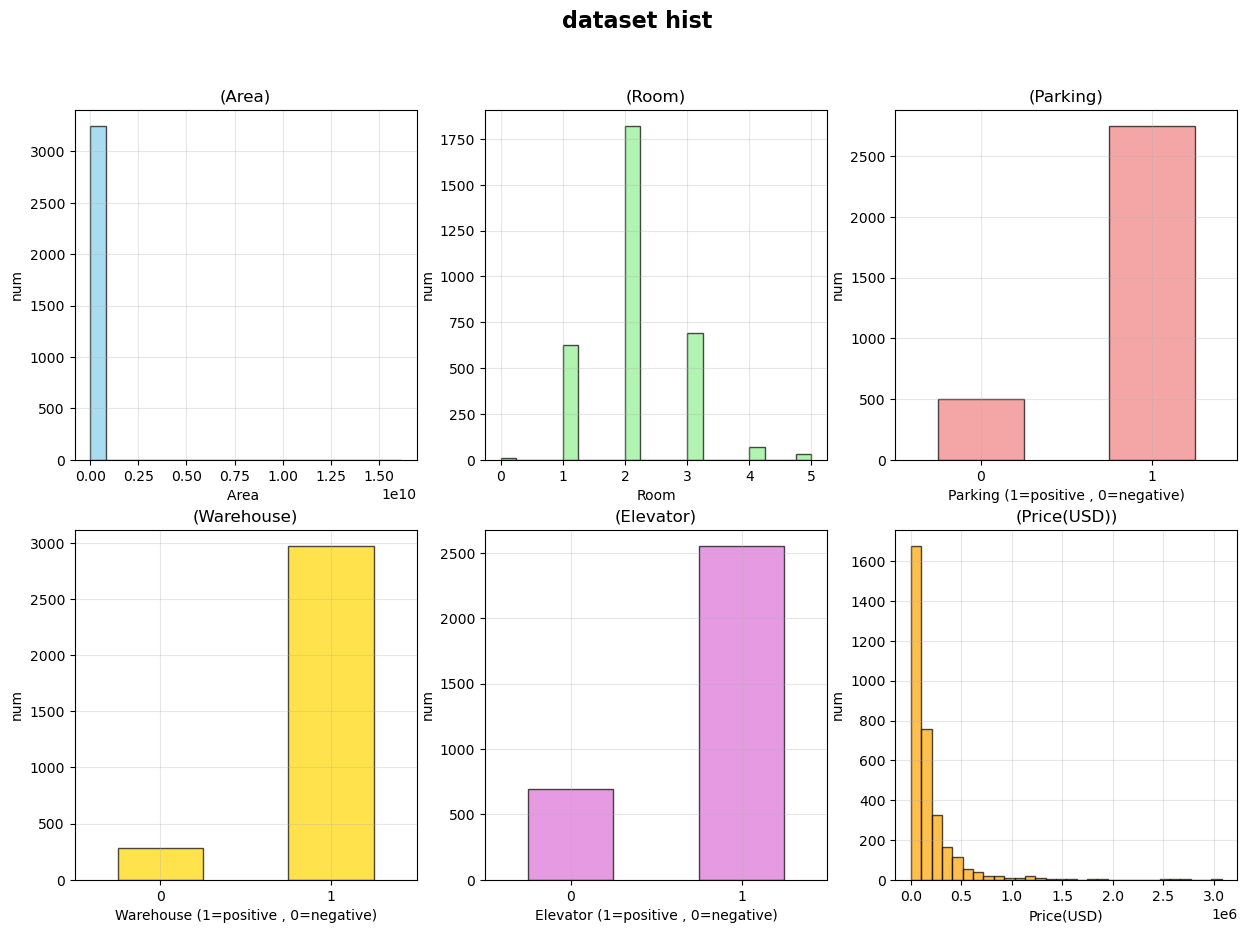

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('dataset hist', fontsize=16, fontweight='bold')
axes[0, 0].hist(df['Area'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('(Area)')
axes[0, 0].set_xlabel('Area ')
axes[0, 0].set_ylabel('num')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(df['Room'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('(Room)')
axes[0, 1].set_xlabel('Room')
axes[0, 1].set_ylabel('num')
axes[0, 1].grid(True, alpha=0.3)



axes[0, 2].hist(df['Parking'], bins=[-0.5, 0.5, 1.5], color='lightcoral', edgecolor='black', alpha=0.7, rwidth=0.5)
axes[0, 2].set_title('(Parking)')
axes[0, 2].set_xlabel('Parking (1=positive , 0=negative)')
axes[0, 2].set_ylabel('num')
axes[0, 2].set_xticks([0, 1])
axes[0, 2].set_xlim(-0.5, 1.5)
axes[0, 2].grid(True, alpha=0.3)


axes[1, 0].hist(df['Warehouse'],bins=[-0.5, 0.5, 1.5], color='gold', edgecolor='black', alpha=0.7, rwidth=0.5)
axes[1, 0].set_title('(Warehouse)')
axes[1, 0].set_xlabel('Warehouse (1=positive , 0=negative)')
axes[1, 0].set_ylabel('num')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xlim(-0.5, 1.5)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(df['Elevator'], bins=[-0.5, 0.5, 1.5], color='orchid', edgecolor='black', alpha=0.7, rwidth=0.5)
axes[1, 1].set_title('(Elevator)')
axes[1, 1].set_xlabel('Elevator (1=positive , 0=negative)')
axes[1, 1].set_ylabel('num')
axes[1, 1].set_xlim(-0.5, 1.5)
axes[1, 1].set_xticks([0, 1])
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].hist(df['Price(USD)'], bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[1, 2].set_title('(Price(USD))')
axes[1, 2].set_xlabel('Price(USD)')
axes[1, 2].set_ylabel('num')
axes[1, 2].grid(True, alpha=0.3)

In [8]:
correlation_with_price = df[['Area','Room','Parking','Warehouse','Elevator','Price(USD)']].corr()['Price(USD)'].sort_values(ascending=False)
print("همبستگی با Price(USD):")
print(correlation_with_price)

همبستگی با Price(USD):
Price(USD)    1.000000
Room          0.569863
Parking       0.193297
Elevator      0.109888
Warehouse     0.108747
Area          0.021028
Name: Price(USD), dtype: float64


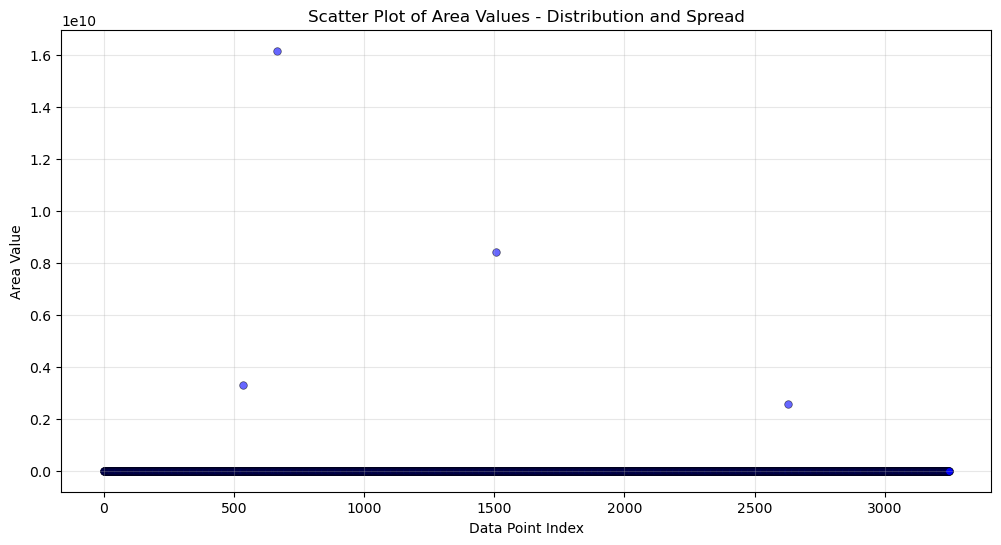

In [9]:
plt.figure(figsize=(12, 6))
plt.scatter(range(len(df)), df['Area'], alpha=0.6, color='blue', s=30, edgecolors='black', linewidth=0.5)
plt.title('Scatter Plot of Area Values - Distribution and Spread')
plt.xlabel('Data Point Index')
plt.ylabel('Area Value')
plt.grid(True, alpha=0.3)

In [10]:
Q1 = df['Area'].quantile(0.25)
Q3 = df['Area'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 4 * IQR  
upper_bound = Q3 + 4 * IQR
df_filtered = df[(df['Area'] >= lower_bound) & (df['Area'] <= upper_bound)]
df_filtered = df_filtered.dropna(subset=['Address'])

In [13]:
Q1 = df_filtered['Price(USD)'].quantile(0.25)
Q3 = df_filtered['Price(USD)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 5 * IQR  
upper_bound = Q3 + 5 * IQR
df_filtered = df_filtered[(df_filtered['Price(USD)'] >= lower_bound) & (df_filtered['Price(USD)'] <= upper_bound)]
df_filtered

,Area,Room,Parking,Warehouse,Elevator,Address,Price(USD)
0,63,1,1,1,1,Shahran,61666.67
1,60,1,1,1,1,Shahran,61666.67
2,79,2,1,1,1,Pardis,18333.33
3,95,2,1,1,1,Shahrake Qods,30083.33
4,123,2,1,1,1,Shahrake Gharb,233333.33
...,...,...,...,...,...,...,...
3473,63,1,1,1,0,Feiz Garden,63000.00
3474,86,2,1,1,1,Southern Janatabad,116666.67
3475,83,2,1,1,1,Niavaran,226666.67
3477,105,2,1,1,1,Dorous,186666.67


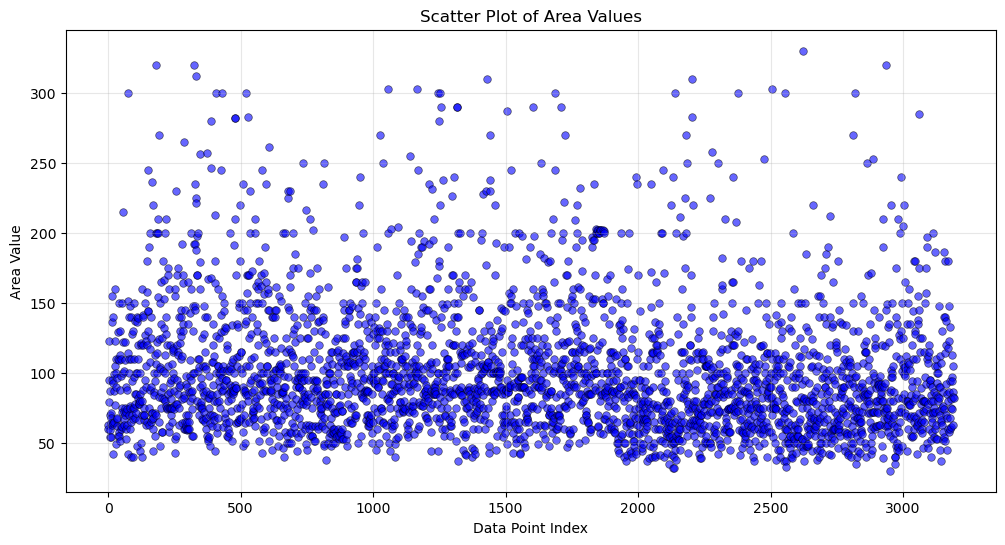

In [11]:
plt.figure(figsize=(12, 6))
plt.scatter(range(len(df_filtered)), df_filtered['Area'], alpha=0.6, color='blue', s=30, edgecolors='black', linewidth=0.5)
plt.title('Scatter Plot of Area Values')
plt.xlabel('Data Point Index')
plt.ylabel('Area Value')
plt.grid(True, alpha=0.3)

In [ ]:
correlation_with_price = df_filtered[['Area','Room','Parking','Warehouse','Elevator','Price(USD)']].corr()['Price(USD)'].sort_values(ascending=False)
print("همبستگی با Price(USD):")
print(correlation_with_price)

همبستگی با Price(USD):
Price(USD)    1.000000
Area          0.775213
Room          0.578194
Parking       0.285405
Elevator      0.252872
Warehouse     0.163329
Name: Price(USD), dtype: float64


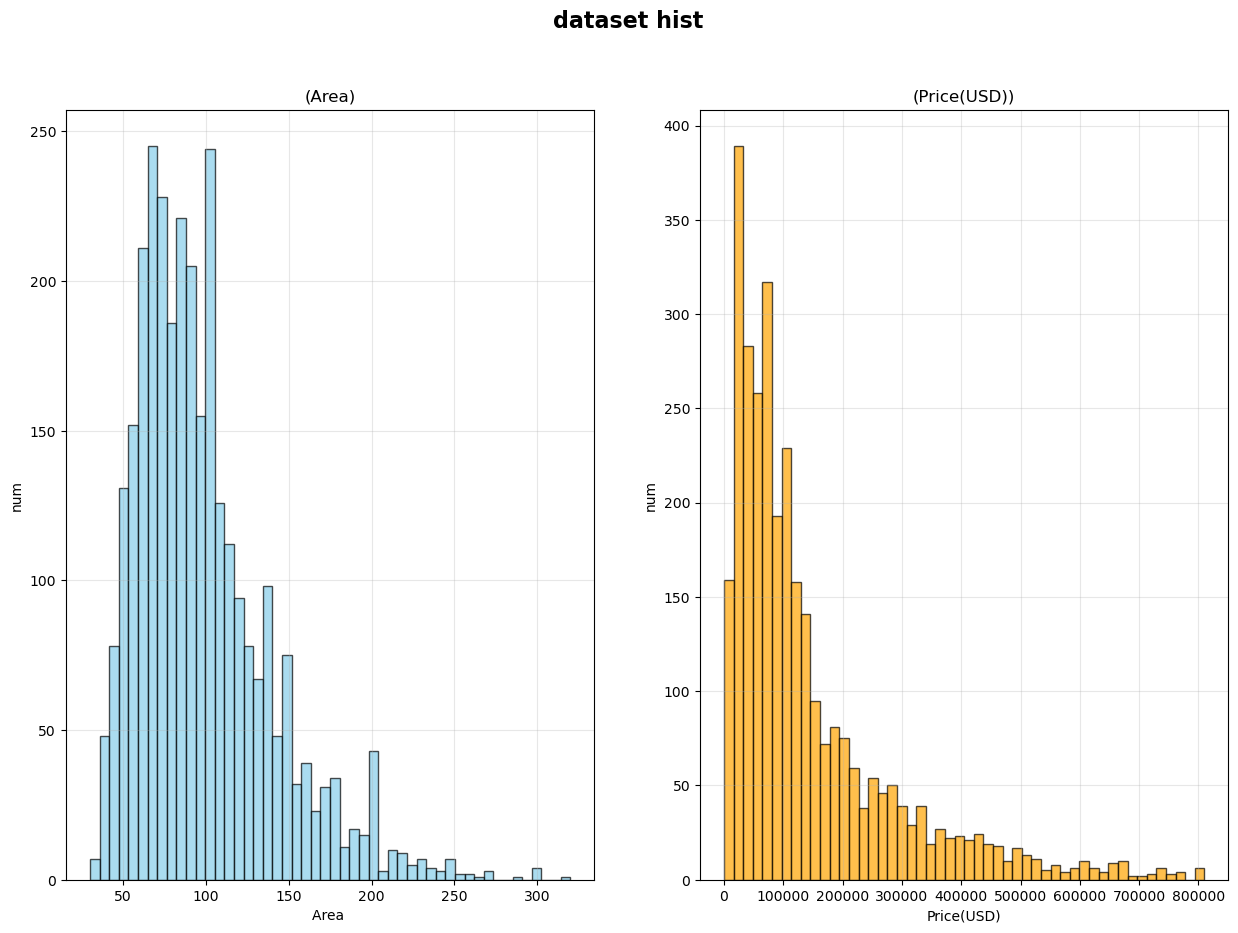

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.suptitle('dataset hist', fontsize=16, fontweight='bold')
axes[0].hist(df_filtered['Area'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('(Area)')
axes[0].set_xlabel('Area ')
axes[0].set_ylabel('num')
axes[0].grid(True, alpha=0.3)


axes[1].hist(df_filtered['Price(USD)'], bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[1].set_title('(Price(USD))')
axes[1].set_xlabel('Price(USD)')
axes[1].set_ylabel('num')
axes[1].grid(True, alpha=0.3)

In [17]:
# df_filtered['Address'].value_counts()

Address
Punak                     148
West Ferdows Boulevard    133
Gheitarieh                126
Pardis                    123
Shahran                   123
                         ... 
Firoozkooh                  1
Shadabad                    1
Naziabad                    1
Javadiyeh                   1
Yakhchiabad                 1
Name: count, Length: 188, dtype: int64

In [1]:
# unique_addresses = address_counts[address_counts == 1].index.tolist()
# print(len(unique_addresses))

___Creating the model___

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
numeric_features = ['Area', 'Room', 'Parking', 'Warehouse', 'Elevator']
categorical_features = ['Address']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

In [20]:
x=df_filtered.drop('Price(USD)',axis=1)
y=df_filtered['Price(USD)']

In [21]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(
        objective='reg:squarederror',
        max_depth=8,
        learning_rate=0.05,
        n_estimators=200,
        eval_metric='rmse'
    ))
])

In [23]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Area', 'Room', 'Parking',
                                                   'Warehouse', 'Elevator']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Address'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None,...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=8, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [25]:
from sklearn.metrics import r2_score, mean_squared_error

preds = pipeline.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f'Root Mean Squared Error: {rmse}')
print("R² Score:", r2_score(y_test, preds))

Root Mean Squared Error: 55380.51200248173
R² Score: 0.8406392004433219


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
